--- 1. EXTRACCIÓN Y CARGA ---
Dataset cargado: 7267 filas y 21 columnas.

--- 2. TRANSFORMACIÓN (LIMPIEZA) ---
Valores nulos encontrados:
 0

--- 3. ANÁLISIS EXPLORATORIO (EDA) ---
Tasa de Evasión Actual: 25.72%


/tmp/ipykernel_917/3727888551.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


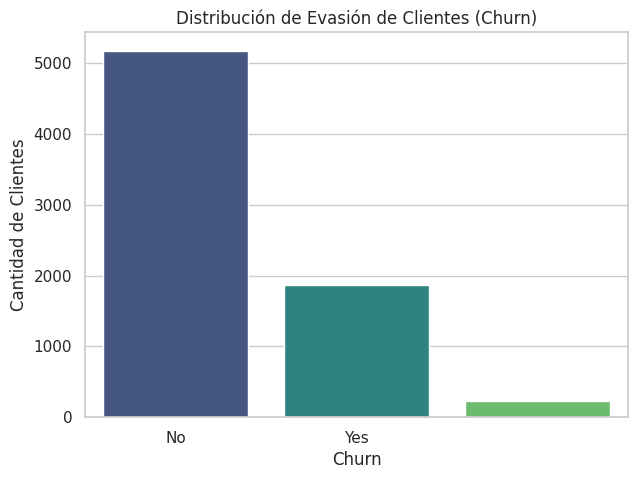

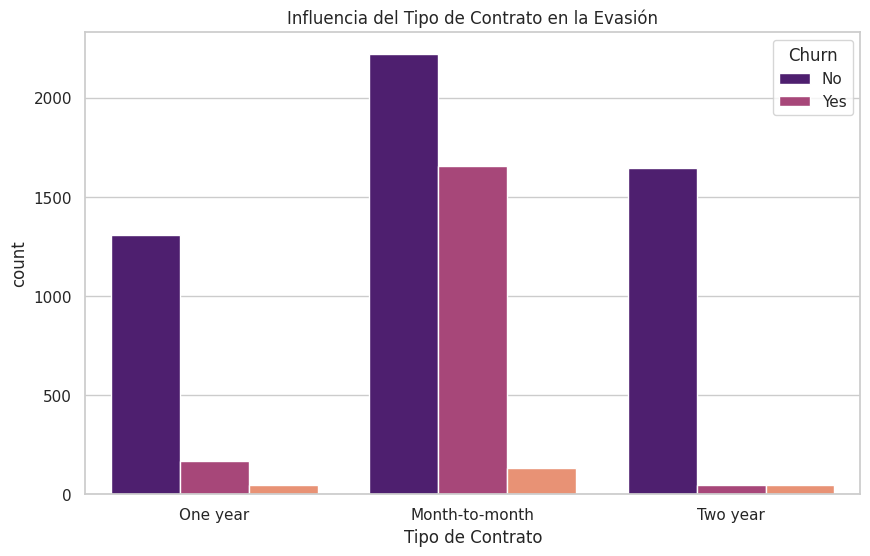

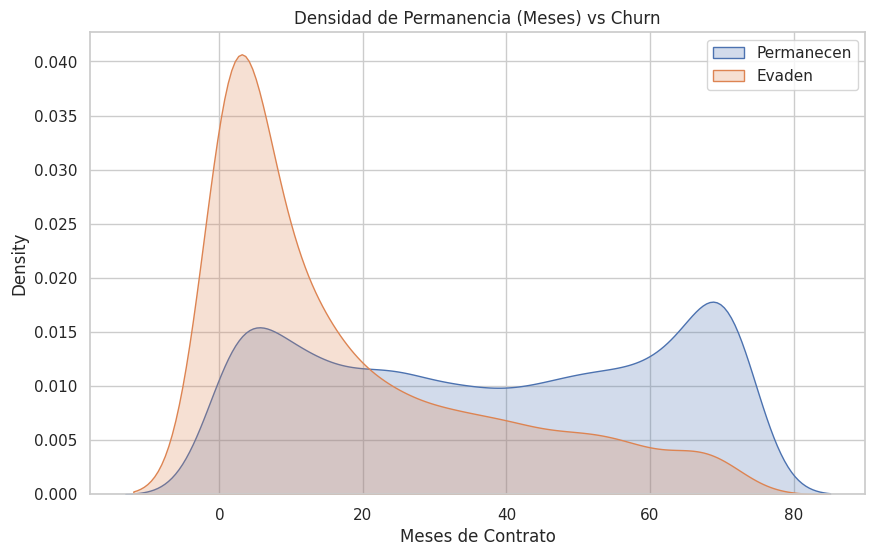

/tmp/ipykernel_917/3727888551.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, palette='Set2')


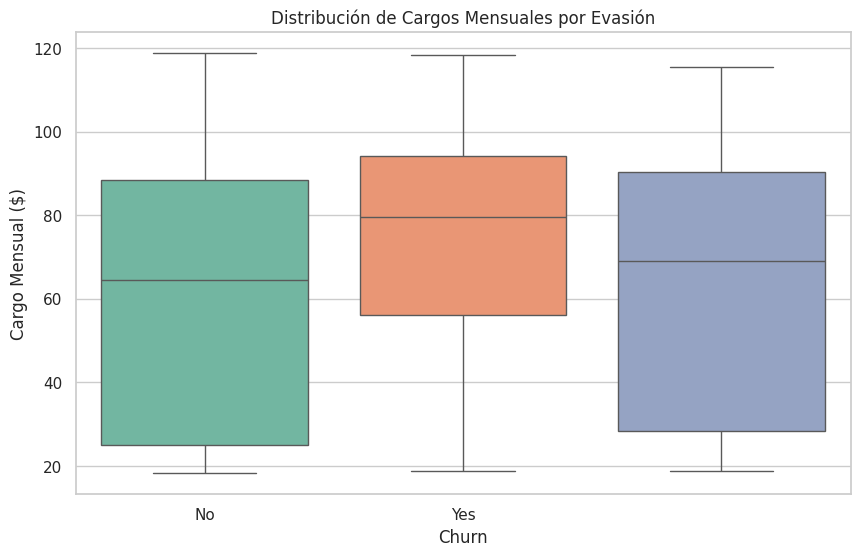


--- 4. CONCLUSIONES PRELIMINARES PARA CIENCIA DE DATOS ---
- Riesgo Crítico: Los clientes con contrato 'Month-to-month' son los más propensos a la evasión.
- Ciclo de Vida: El cliente que evade lo hace, en promedio, a los 18.0 meses.

Archivo 'TelecomX_Data_Clean.csv' generado para el equipo de Ciencia de Datos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configuración de estilo para gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def analizar_evasion_telecom():
    print("--- 1. EXTRACCIÓN Y CARGA ---")

    # Cargar el archivo JSON
    try:
        with open('TelecomX_Data.json', 'r') as f:
            datos_json = json.load(f)

        # Aplanar la estructura anidada del JSON para convertirlo en tabla
        df = pd.json_normalize(datos_json)
        print(f"Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas.")
    except Exception as e:
        print(f"Error al cargar datos: {e}")
        return

    print("\n--- 2. TRANSFORMACIÓN (LIMPIEZA) ---")

    # Renombrar columnas para facilitar el manejo (quitar los puntos de la normalización)
    df.columns = [col.replace('.', '_') for col in df.columns]

    # Corregir tipos de datos: account_Charges_Total suele venir como string en JSON
    # Reemplazamos espacios vacíos por NaN y convertimos a numérico
    df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

    # Llenar valores nulos en el Total con 0 (clientes nuevos con tenure 0)
    df['account_Charges_Total'] = df['account_Charges_Total'].fillna(0)

    # Verificar valores nulos generales
    print("Valores nulos encontrados:\n", df.isnull().sum().sum())

    # Eliminar posibles duplicados
    df.drop_duplicates(inplace=True)

    print("\n--- 3. ANÁLISIS EXPLORATORIO (EDA) ---")

    # Distribución del Churn (Evasión)
    evasion_counts = df['Churn'].value_counts(normalize=True) * 100
    print(f"Tasa de Evasión Actual: {evasion_counts['Yes']:.2f}%")

    # Gráfico 1: Tasa de Churn
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x='Churn', palette='viridis')
    plt.title('Distribución de Evasión de Clientes (Churn)')
    plt.ylabel('Cantidad de Clientes')
    plt.show()

    # Gráfico 2: Contrato vs Churn (Hipótesis: Contratos cortos evaden más)
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='account_Contract', hue='Churn', palette='magma')
    plt.title('Influencia del Tipo de Contrato en la Evasión')
    plt.xlabel('Tipo de Contrato')
    plt.show()

    # Gráfico 3: Tenure (Meses de permanencia) vs Churn
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df[df['Churn'] == 'No']['customer_tenure'], label='Permanecen', fill=True)
    sns.kdeplot(df[df['Churn'] == 'Yes']['customer_tenure'], label='Evaden', fill=True)
    plt.title('Densidad de Permanencia (Meses) vs Churn')
    plt.xlabel('Meses de Contrato')
    plt.legend()
    plt.show()

    # Gráfico 4: Cargos Mensuales vs Churn
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, palette='Set2')
    plt.title('Distribución de Cargos Mensuales por Evasión')
    plt.ylabel('Cargo Mensual ($)')
    plt.show()

    print("\n--- 4. CONCLUSIONES PRELIMINARES PARA CIENCIA DE DATOS ---")

    # Hallazgo sobre contratos
    top_contract_churn = df[df['Churn'] == 'Yes']['account_Contract'].value_counts().idxmax()
    print(f"- Riesgo Crítico: Los clientes con contrato '{top_contract_churn}' son los más propensos a la evasión.")

    # Hallazgo sobre antigüedad
    avg_tenure_churn = df[df['Churn'] == 'Yes']['customer_tenure'].mean()
    print(f"- Ciclo de Vida: El cliente que evade lo hace, en promedio, a los {avg_tenure_churn:.1f} meses.")

    # Guardar datos limpios para el siguiente equipo
    df.to_csv('TelecomX_Data_Clean.csv', index=False)

# Ejecutar el script
if __name__ == "__main__":
    analizar_evasion_telecom()